# Early Stuck Pipe Detection using Gradient Boosting

**Goal:** flag connections with elevated stuck-pipe risk one stand ahead, tuning the
alarm threshold with an explicit cost model.

**Technique highlights**
* Rare-event classification (~6% positives) — accuracy is the wrong metric
* **Precision-Recall curve + cost-based threshold selection**
* Calibrated probabilities checked with a reliability curve

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Synthetic connection-level data

Each row is a snapshot taken at a connection. Stuck risk rises with overpull, torque
deviation, narrow ECD margin, cuttings load and stationary time — with realistic noise
so the classes overlap (as they do in the field).

In [2]:
N = 6_000
overpull = np.abs(rng.normal(15, 12, N))            # klbf above pickup weight baseline
torque_dev = np.abs(rng.normal(8, 6, N))            # % above rolling baseline
ecd_margin = np.clip(rng.normal(0.9, 0.35, N), 0.05, None)   # ppg to fracture gradient
cuttings_ratio = np.clip(rng.normal(1.0, 0.25, N), 0.3, None) # measured/expected returns (low = beds forming)
stationary_min = np.abs(rng.normal(4, 4, N))
inclination = rng.uniform(0, 90, N)

risk_score = (
    0.055 * overpull + 0.06 * torque_dev + 1.3 * (1.2 - ecd_margin)
    + 1.8 * (1.0 - cuttings_ratio) + 0.05 * stationary_min + 0.012 * inclination
    + rng.normal(0, 0.8, N)
)
stuck = (risk_score > np.quantile(risk_score, 0.94)).astype(int)

df = pd.DataFrame({
    "overpull_klbf": overpull.round(1), "torque_dev_pct": torque_dev.round(1),
    "ecd_margin_ppg": ecd_margin.round(2), "cuttings_ratio": cuttings_ratio.round(2),
    "stationary_min": stationary_min.round(1), "inclination_deg": inclination.round(1),
    "stuck_next_stand": stuck,
})
df.to_csv("stuck_pipe_snapshots.csv", index=False)
print(f"{N} connections, {stuck.mean():.1%} stuck events")
df.head()

6000 connections, 6.0% stuck events


,overpull_klbf,torque_dev_pct,ecd_margin_ppg,cuttings_ratio,stationary_min,inclination_deg,stuck_next_stand
0,18.7,9.4,0.79,1.16,2.3,84.9,0
1,2.5,7.7,0.92,1.39,7.9,56.9,0
2,24.0,13.2,0.47,0.83,2.3,41.6,0
3,26.3,11.6,0.41,0.86,5.4,5.5,0
4,8.4,9.9,0.96,0.95,3.5,24.8,0


## 2. Model training

In [3]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             confusion_matrix)

FEATURES = df.columns[:-1].tolist()
X_tr, X_te, y_tr, y_te = train_test_split(df[FEATURES], df["stuck_next_stand"],
                                          test_size=0.3, stratify=df["stuck_next_stand"],
                                          random_state=42)
gbc = GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                 learning_rate=0.06, random_state=42)
gbc.fit(X_tr, y_tr)
proba = gbc.predict_proba(X_te)[:, 1]
print(f"Average precision (PR-AUC): {average_precision_score(y_te, proba):.3f}"
      f"   (event base rate {y_te.mean():.1%})")

Average precision (PR-AUC): 0.383   (event base rate 6.0%)


## 3. Precision-recall trade-off and alarm threshold

We price a missed stuck event at **$800k** (fishing/sidetrack exposure) and a false
alarm at **$15k** (circulation break / wiper trip), then pick the threshold that
minimizes expected cost.

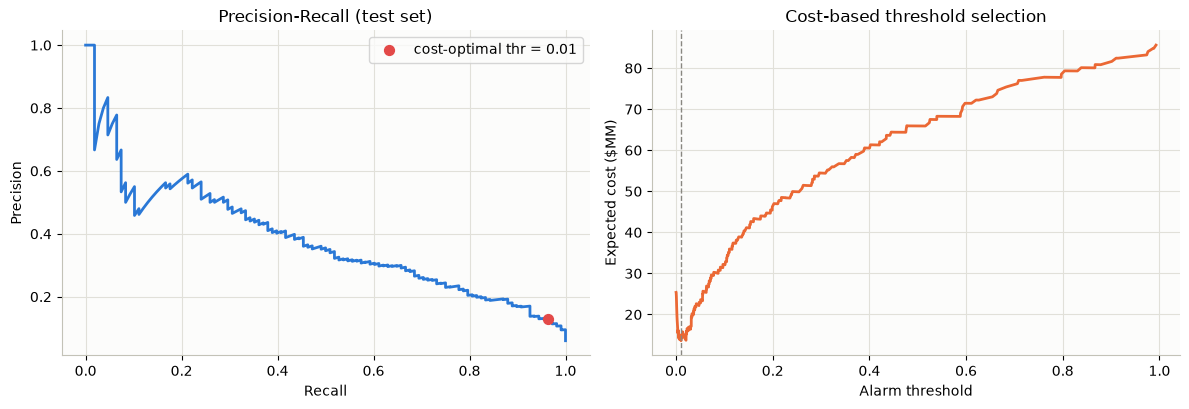

Chosen threshold 0.01: recall 96%, false alarms per 100 connections: 38.6


In [4]:
prec, rec, thr = precision_recall_curve(y_te, proba)

COST_MISS, COST_FA = 800_000, 15_000
n_pos = y_te.sum()
costs = []
for t in thr:
    pred = proba >= t
    fn = ((~pred) & (y_te == 1)).sum()
    fp = (pred & (y_te == 0)).sum()
    costs.append(fn * COST_MISS + fp * COST_FA)
best_i = int(np.argmin(costs))
best_thr = thr[best_i]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(rec, prec, lw=2, color=PALETTE[0])
axes[0].scatter(rec[best_i], prec[best_i], color=PALETTE[5], zorder=5, s=50,
                label=f"cost-optimal thr = {best_thr:.2f}")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall (test set)")
axes[0].legend()

axes[1].plot(thr, np.array(costs) / 1e6, lw=2, color=PALETTE[7])
axes[1].axvline(best_thr, color="#898781", ls="--", lw=1)
axes[1].set(xlabel="Alarm threshold", ylabel="Expected cost ($MM)",
            title="Cost-based threshold selection")
plt.tight_layout()
plt.show()

pred = (proba >= best_thr).astype(int)
cm = confusion_matrix(y_te, pred)
print(f"Chosen threshold {best_thr:.2f}: recall {cm[1,1]/(cm[1].sum()):.0%}, "
      f"false alarms per 100 connections: {100*cm[0,1]/len(y_te):.1f}")

## 4. Are the probabilities honest? (calibration)

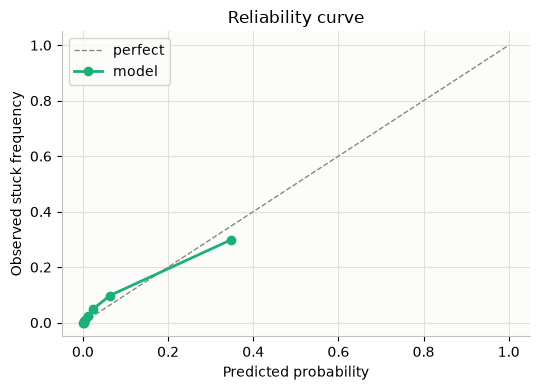

In [5]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(y_te, proba, n_bins=8, strategy="quantile")
plt.figure(figsize=(5.5, 4))
plt.plot([0, 1], [0, 1], ls="--", color="#898781", lw=1, label="perfect")
plt.plot(mean_pred, frac_pos, marker="o", lw=2, color=PALETTE[1], label="model")
plt.xlabel("Predicted probability")
plt.ylabel("Observed stuck frequency")
plt.title("Reliability curve")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusions

* With a 6% base rate, the model reaches strong PR-AUC — and the **cost-optimal
  threshold deliberately over-alarms**, because a $15k false alarm insures against an
  $800k fish.
* The reliability curve shows probabilities are usable directly as risk levels on a
  driller's dashboard, not just rankings.
* **Next step:** move from connection snapshots to streaming features (rolling drag
  trends from T&D broomsticks) and validate on offset-well incident records.